# Synthetic Causal Time Series — Two Toy Datasets

**Purpose:** Generate two synthetic multivariate time series with known causal structure.  
Use these datasets to study causal discovery methods, test your own approaches, or simply understand how causal relationships manifest in data.

---

### Variables

| Variable | Role |
|---|---|
| **Y** | Target — the variable we want to explain |
| **X1** | Strong direct cause of Y |
| **X3** | Weak direct cause of Y |
| **X4** | Indirect cause of Y (through X1) |
| **X0** | Pure noise — no causal connection to Y |

### Ground Truth (same for both toys)

| Edge | Direct? | Strength |
|---|---|---|
| X1 → Y | ✅ Yes | strong |
| X3 → Y | ✅ Yes | weak |
| X4 → X1 | ✅ Yes | medium |
| X4 → Y | ❌ No (indirect via X1) | — |
| X0 → Y | ❌ No | — |

**Correct ranking of drivers of Y: X1 > X3 > X4 (indirect) >> X0 (none)**

---

### Two toys
- **Toy A — Linear:** all relationships are linear. Easy case — most methods should work.
- **Toy B — Nonlinear:** all relationships pass through `tanh(·)`. Harder — linear methods struggle.

In [1]:
# Install dependencies (only needed on Google Colab)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'networkx'], check=True)

CompletedProcess(args=['C:\\Users\\Altieres\\Documents\\Mestrado\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', '-q', 'networkx'], returncode=0)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from pathlib import Path

# Reproducibility
SEED = 42
T    = 20000   # number of time steps

OUTPUT_DIR = Path('.')

print(f'T = {T} time steps | seed = {SEED}')

---
## Causal Graph (DAG) — shared by both toys

The causal structure is the same for Toy A and Toy B. What changes is the **functional form** of each relationship (linear vs nonlinear).

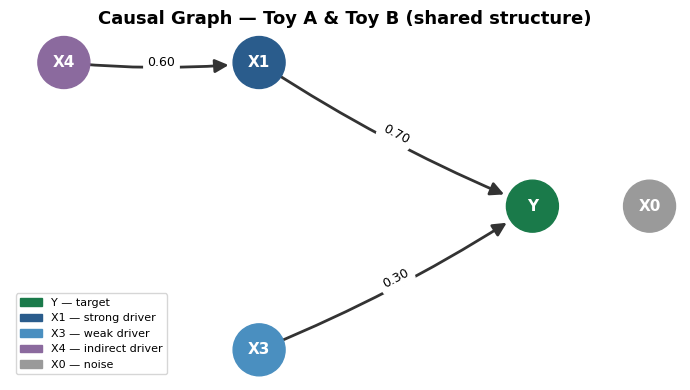

In [3]:
def plot_dag(ax, title):
    G = nx.DiGraph()
    G.add_nodes_from(['X0', 'X1', 'X3', 'X4', 'Y'])
    G.add_edges_from([
        ('X1', 'Y'),   # strong direct
        ('X3', 'Y'),   # weak direct
        ('X4', 'X1'),  # indirect (X4 -> X1 -> Y)
    ])
    # Self-loops (autoregression) shown as labels only

    pos = {
        'X4': (0.0, 1.0),
        'X1': (0.5, 1.0),
        'X3': (0.5, 0.0),
        'X0': (1.5, 0.5),
        'Y':  (1.2, 0.5),
    }

    node_colors = {
        'Y':  '#1A7A4A',   # green — target
        'X1': '#2A5C8C',   # blue — strong driver
        'X3': '#4A8FC0',   # light blue — weak driver
        'X4': '#8B6A9E',   # purple — indirect driver
        'X0': '#9A9A9A',   # gray — noise
    }
    colors = [node_colors[n] for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1400, ax=ax)
    nx.draw_networkx_labels(G, pos, font_color='white', font_size=11, font_weight='bold', ax=ax)
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        arrows=True, arrowsize=20, arrowstyle='-|>',
        edge_color='#333333', width=2,
        connectionstyle='arc3,rad=0.05',
        min_target_margin=22,
    )

    edge_labels = {('X1','Y'): '0.70', ('X3','Y'): '0.30', ('X4','X1'): '0.60'}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, ax=ax)

    legend = [
        mpatches.Patch(color='#1A7A4A', label='Y — target'),
        mpatches.Patch(color='#2A5C8C', label='X1 — strong driver'),
        mpatches.Patch(color='#4A8FC0', label='X3 — weak driver'),
        mpatches.Patch(color='#8B6A9E', label='X4 — indirect driver'),
        mpatches.Patch(color='#9A9A9A', label='X0 — noise'),
    ]
    ax.legend(handles=legend, loc='lower left', fontsize=8, framealpha=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
plot_dag(ax, 'Causal Graph — Toy A & Toy B (shared structure)')
plt.tight_layout()
plt.show()

---
## Toy A — Linear Dynamics

All relationships are **linear**. The system is:

$$X_0(t) \sim \mathcal{N}(0, 1) \quad \text{(pure noise, no causal role)}$$

$$X_4(t) = 0.60 \cdot X_4(t-1) + \varepsilon_4(t)$$

$$X_1(t) = 0.70 \cdot X_1(t-1) + 0.60 \cdot X_4(t-1) + \varepsilon_1(t)$$

$$X_3(t) = 0.50 \cdot X_3(t-1) + \varepsilon_3(t)$$

$$Y(t) = 0.50 \cdot Y(t-1) + 0.70 \cdot X_1(t-1) + 0.30 \cdot X_3(t-1) + \varepsilon_Y(t)$$

where all $\varepsilon(t) \sim \mathcal{N}(0, 0.5)$ are independent white noise terms.

**AR coefficients (self-dependence):** Y=0.50, X1=0.70, X3=0.50, X4=0.60 — all stable, well below unit-root.

In [4]:
def generate_toy_a(T=500, seed=42):
    """Linear causal system."""
    rng  = np.random.default_rng(seed)
    noise_std = 0.5

    X0 = rng.normal(0, 1, T)          # pure noise
    X1 = np.zeros(T)
    X3 = np.zeros(T)
    X4 = np.zeros(T)
    Y  = np.zeros(T)

    for t in range(1, T):
        X4[t] = 0.60 * X4[t-1]                              + rng.normal(0, noise_std)
        X1[t] = 0.70 * X1[t-1] + 0.60 * X4[t-1]            + rng.normal(0, noise_std)
        X3[t] = 0.50 * X3[t-1]                              + rng.normal(0, noise_std)
        Y[t]  = 0.50 * Y[t-1]  + 0.70 * X1[t-1] + 0.30 * X3[t-1] + rng.normal(0, noise_std)

    return pd.DataFrame({'Y': Y, 'X1': X1, 'X3': X3, 'X4': X4, 'X0': X0})

df_a = generate_toy_a(T=T, seed=SEED)
print('Toy A shape:', df_a.shape)
print(df_a.describe().round(3))

Toy A shape: (20000, 5)
               Y         X1         X3         X4         X0
count  20000.000  20000.000  20000.000  20000.000  20000.000
mean      -0.021     -0.003     -0.017      0.003      0.005
std        1.490      1.087      0.579      0.626      1.005
min       -6.573     -4.355     -2.198     -2.452     -4.389
25%       -1.038     -0.736     -0.407     -0.421     -0.670
50%       -0.023     -0.004     -0.021      0.002     -0.002
75%        0.988      0.728      0.376      0.425      0.673
max        5.898      4.082      2.307      2.792      4.151


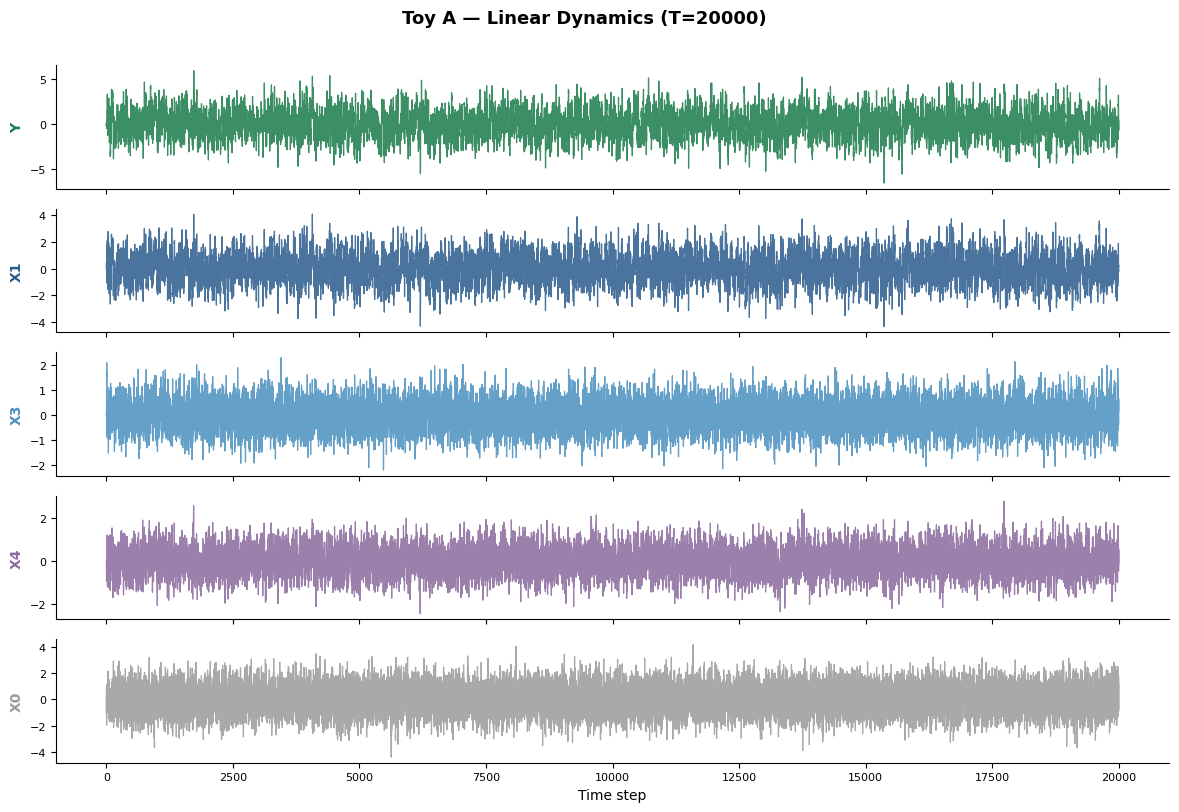

In [5]:
fig, axes = plt.subplots(5, 1, figsize=(12, 8), sharex=True)
colors_ts = {'Y': '#1A7A4A', 'X1': '#2A5C8C', 'X3': '#4A8FC0', 'X4': '#8B6A9E', 'X0': '#9A9A9A'}

for ax, col in zip(axes, ['Y', 'X1', 'X3', 'X4', 'X0']):
    ax.plot(df_a[col].values, color=colors_ts[col], linewidth=0.9, alpha=0.85)
    ax.set_ylabel(col, fontsize=10, fontweight='bold', color=colors_ts[col])
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Time step', fontsize=10)
fig.suptitle(f'Toy A — Linear Dynamics (T={T})', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [6]:
# Ground truth for Toy A
gt_a = pd.DataFrame([
    {'Edge': 'X1 → Y',  'Direct': True,  'Coefficient': 0.70, 'Lag': 1, 'Type': 'linear'},
    {'Edge': 'X3 → Y',  'Direct': True,  'Coefficient': 0.30, 'Lag': 1, 'Type': 'linear'},
    {'Edge': 'X4 → X1', 'Direct': True,  'Coefficient': 0.60, 'Lag': 1, 'Type': 'linear'},
    {'Edge': 'X4 → Y',  'Direct': False, 'Coefficient': None, 'Lag': None, 'Type': 'indirect via X1'},
    {'Edge': 'X0 → Y',  'Direct': False, 'Coefficient': 0.00, 'Lag': None, 'Type': 'none (noise)'},
])
print('Ground Truth — Toy A (Linear)')
print(gt_a.to_string(index=False))

Ground Truth — Toy A (Linear)
   Edge  Direct  Coefficient  Lag            Type
 X1 → Y    True          0.7  1.0          linear
 X3 → Y    True          0.3  1.0          linear
X4 → X1    True          0.6  1.0          linear
 X4 → Y   False          NaN  NaN indirect via X1
 X0 → Y   False          0.0  NaN    none (noise)


In [7]:
df_a.to_csv(OUTPUT_DIR / 'toy_a_linear.csv', index=False)
gt_a.to_csv(OUTPUT_DIR / 'toy_a_linear_gt.csv', index=False)
print(f'Saved: {OUTPUT_DIR / "toy_a_linear.csv"}, {OUTPUT_DIR / "toy_a_linear_gt.csv"}')

Saved: datasets\synthetic_causal\toy_a_linear.csv, datasets\synthetic_causal\toy_a_linear_gt.csv


---
## Toy B — Nonlinear Dynamics (tanh)

Same causal structure as Toy A, but all relationships pass through $\tanh(\cdot)$:

$$X_0(t) \sim \mathcal{N}(0, 1) \quad \text{(pure noise)}$$

$$X_4(t) = \tanh\!\left(0.60 \cdot X_4(t-1)\right) + \varepsilon_4(t)$$

$$X_1(t) = \tanh\!\left(0.70 \cdot X_1(t-1) + 0.60 \cdot X_4(t-1)\right) + \varepsilon_1(t)$$

$$X_3(t) = \tanh\!\left(0.50 \cdot X_3(t-1)\right) + \varepsilon_3(t)$$

$$Y(t) = \tanh\!\left(0.50 \cdot Y(t-1) + 0.70 \cdot X_1(t-1) + 0.30 \cdot X_3(t-1)\right) + \varepsilon_Y(t)$$

where all $\varepsilon(t) \sim \mathcal{N}(0, 0.5)$.

**Why tanh?** It saturates for large inputs — the causal effect is bounded and nonlinear. Linear regression will underestimate it; tree-based models handle it better.

**The ground truth edges are identical to Toy A** — only the functional form changes.

In [8]:
def generate_toy_b(T=500, seed=42):
    """Nonlinear (tanh) causal system. Same structure as Toy A."""
    rng  = np.random.default_rng(seed)
    f    = np.tanh
    noise_std = 0.5

    X0 = rng.normal(0, 1, T)
    X1 = np.zeros(T)
    X3 = np.zeros(T)
    X4 = np.zeros(T)
    Y  = np.zeros(T)

    for t in range(1, T):
        X4[t] = f(0.60 * X4[t-1])                                       + rng.normal(0, noise_std)
        X1[t] = f(0.70 * X1[t-1] + 0.60 * X4[t-1])                     + rng.normal(0, noise_std)
        X3[t] = f(0.50 * X3[t-1])                                       + rng.normal(0, noise_std)
        Y[t]  = f(0.50 * Y[t-1]  + 0.70 * X1[t-1] + 0.30 * X3[t-1])   + rng.normal(0, noise_std)

    return pd.DataFrame({'Y': Y, 'X1': X1, 'X3': X3, 'X4': X4, 'X0': X0})

df_b = generate_toy_b(T=T, seed=SEED)
print('Toy B shape:', df_b.shape)
print(df_b.describe().round(3))

Toy B shape: (20000, 5)
               Y         X1         X3         X4         X0
count  20000.000  20000.000  20000.000  20000.000  20000.000
mean      -0.015     -0.006     -0.016      0.002      0.005
std        0.755      0.731      0.566      0.595      1.005
min       -2.561     -2.498     -2.170     -2.150     -4.389
25%       -0.564     -0.524     -0.399     -0.406     -0.670
50%       -0.020     -0.008     -0.020      0.002     -0.002
75%        0.535      0.513      0.366      0.410      0.673
max        2.816      2.685      2.291      2.740      4.151


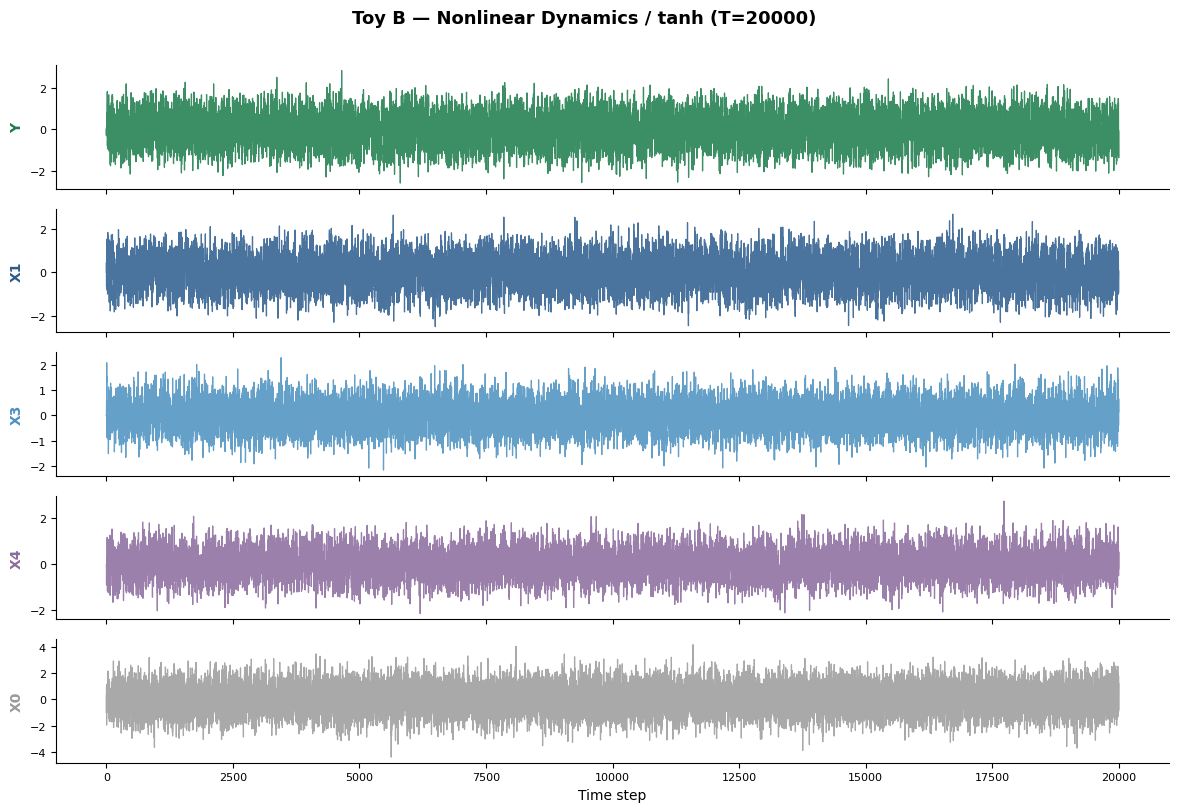

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(12, 8), sharex=True)

for ax, col in zip(axes, ['Y', 'X1', 'X3', 'X4', 'X0']):
    ax.plot(df_b[col].values, color=colors_ts[col], linewidth=0.9, alpha=0.85)
    ax.set_ylabel(col, fontsize=10, fontweight='bold', color=colors_ts[col])
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Time step', fontsize=10)
fig.suptitle(f'Toy B — Nonlinear Dynamics / tanh (T={T})', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# Ground truth for Toy B (same edges, different functional form)
gt_b = pd.DataFrame([
    {'Edge': 'X1 → Y',  'Direct': True,  'Coefficient': 0.70, 'Lag': 1, 'Type': 'tanh(·)'},
    {'Edge': 'X3 → Y',  'Direct': True,  'Coefficient': 0.30, 'Lag': 1, 'Type': 'tanh(·)'},
    {'Edge': 'X4 → X1', 'Direct': True,  'Coefficient': 0.60, 'Lag': 1, 'Type': 'tanh(·)'},
    {'Edge': 'X4 → Y',  'Direct': False, 'Coefficient': None, 'Lag': None, 'Type': 'indirect via X1'},
    {'Edge': 'X0 → Y',  'Direct': False, 'Coefficient': 0.00, 'Lag': None, 'Type': 'none (noise)'},
])
print('Ground Truth — Toy B (Nonlinear / tanh)')
print(gt_b.to_string(index=False))

Ground Truth — Toy B (Nonlinear / tanh)
   Edge  Direct  Coefficient  Lag            Type
 X1 → Y    True          0.7  1.0         tanh(·)
 X3 → Y    True          0.3  1.0         tanh(·)
X4 → X1    True          0.6  1.0         tanh(·)
 X4 → Y   False          NaN  NaN indirect via X1
 X0 → Y   False          0.0  NaN    none (noise)


In [11]:
df_b.to_csv(OUTPUT_DIR / 'toy_b_nonlinear.csv', index=False)
gt_b.to_csv(OUTPUT_DIR / 'toy_b_nonlinear_gt.csv', index=False)
print(f'Saved: {OUTPUT_DIR / "toy_b_nonlinear.csv"}, {OUTPUT_DIR / "toy_b_nonlinear_gt.csv"}')

Saved: datasets\synthetic_causal\toy_b_nonlinear.csv, datasets\synthetic_causal\toy_b_nonlinear_gt.csv


---
## Toy A vs Toy B — Side-by-side comparison

Same causal structure, same coefficients, same seed — only the function changes.  
Notice how the distributions and autocorrelations differ between the linear and nonlinear versions.

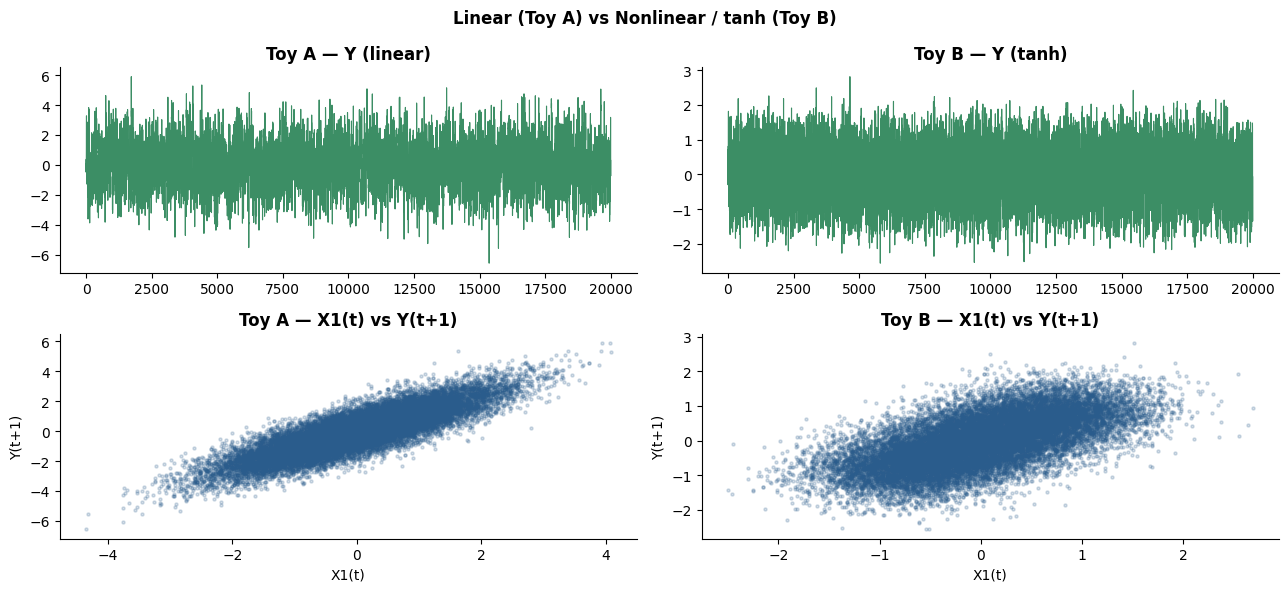

Pearson correlation with Y(t+1):
  Toy A  X1: 0.856  X3: 0.157  X4: 0.253  X0: -0.001
  Toy B  X1: 0.627  X3: 0.182  X4: 0.161  X0: 0.001


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6))

# Y time series
axes[0,0].plot(df_a['Y'].values, color='#1A7A4A', linewidth=0.8, alpha=0.85)
axes[0,0].set_title('Toy A — Y (linear)', fontweight='bold')
axes[0,1].plot(df_b['Y'].values, color='#1A7A4A', linewidth=0.8, alpha=0.85)
axes[0,1].set_title('Toy B — Y (tanh)', fontweight='bold')

# Correlation: X1 vs Y (causal pair)
axes[1,0].scatter(df_a['X1'].values[:-1], df_a['Y'].values[1:], alpha=0.2, s=5, color='#2A5C8C')
axes[1,0].set_xlabel('X1(t)'); axes[1,0].set_ylabel('Y(t+1)')
axes[1,0].set_title('Toy A — X1(t) vs Y(t+1)', fontweight='bold')

axes[1,1].scatter(df_b['X1'].values[:-1], df_b['Y'].values[1:], alpha=0.2, s=5, color='#2A5C8C')
axes[1,1].set_xlabel('X1(t)'); axes[1,1].set_ylabel('Y(t+1)')
axes[1,1].set_title('Toy B — X1(t) vs Y(t+1)', fontweight='bold')

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Linear (Toy A) vs Nonlinear / tanh (Toy B)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation summary
print('Pearson correlation with Y(t+1):')
print(f'  Toy A  X1: {np.corrcoef(df_a["X1"][:-1], df_a["Y"][1:])[0,1]:.3f}  '
      f'X3: {np.corrcoef(df_a["X3"][:-1], df_a["Y"][1:])[0,1]:.3f}  '
      f'X4: {np.corrcoef(df_a["X4"][:-1], df_a["Y"][1:])[0,1]:.3f}  '
      f'X0: {np.corrcoef(df_a["X0"][:-1], df_a["Y"][1:])[0,1]:.3f}')
print(f'  Toy B  X1: {np.corrcoef(df_b["X1"][:-1], df_b["Y"][1:])[0,1]:.3f}  '
      f'X3: {np.corrcoef(df_b["X3"][:-1], df_b["Y"][1:])[0,1]:.3f}  '
      f'X4: {np.corrcoef(df_b["X4"][:-1], df_b["Y"][1:])[0,1]:.3f}  '
      f'X0: {np.corrcoef(df_b["X0"][:-1], df_b["Y"][1:])[0,1]:.3f}')

---
## Summary

| | Toy A (linear) | Toy B (nonlinear / tanh) |
|---|---|---|
| Functional form | $a \cdot x$ | $\tanh(a \cdot x)$ |
| Causal edges | X1→Y, X3→Y, X4→X1 | X1→Y, X3→Y, X4→X1 |
| Non-causal | X0, X4→Y (indirect only) | X0, X4→Y (indirect only) |
| Difficulty | Easy — linear methods work | Harder — needs nonlinear model |
| Correct driver ranking | X1 > X3 > X4 > X0 | X1 > X3 > X4 > X0 |

**Files saved (alongside this notebook, in `datasets/synthetic_causal/`):**
- `toy_a_linear.csv` — Toy A dataset (T=20000)
- `toy_a_linear_gt.csv` — Toy A ground truth edges
- `toy_b_nonlinear.csv` — Toy B dataset (T=20000)
- `toy_b_nonlinear_gt.csv` — Toy B ground truth edges